# Brain Tumor MRI Classification
## Machine Learning and Deep Learning Project

This project was originally developed as part of the WMG9B7 Artificial Intelligence & Deep Learning module and later prepared as a portfolio project.

---

### Problem Statement
This notebook develops and evaluates machine learning and deep learning models to classify brain MRI scans into four categories: **glioma**, **meningioma**, **pituitary tumour**, and **no tumor**. Early and accurate detection of brain tumours from MRI images is clinically significant, as it supports radiologists in diagnosis and can speed up treatment.

### Dataset
- **Source:** [Brain Tumour MRI Dataset – Kaggle](https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset/data)
- **License:** Attribution 4.0 International (CC by 4.0)
- **Classes:** Glioma, Meningioma, Pituitary, No Tumour
- **Size:** 7,200 MRI images (pre-split into Training and Testing folders)

**Expected folder structure after download:**
```data
data/
├── Training/           
│   ├── glioma/         (1400 images)
│   ├── meningioma/     (1400 images)
│   ├── notumor/        (1400 images)
│   └── pituitary/      (1400 images)
└── Testing/
    ├── glioma/         (400 images)
    ├── meningioma/     (400 images)
    ├── notumor/        (400 images)
    └── pituitary/      (400 images)
```


### Models Implemented

This notebook develops and compares four classification models:

| Model | Purpose |
|---|---|
| HOG + SVM | Traditional machine learning baseline using hand-crafted image features |
| Custom CNN | Deep learning baseline trained from scratch |
| ResNet18 | Transfer learning model using an ImageNet-pretrained CNN backbone |
| EfficientNetB0 | Transfer learning model using an ImageNet-pretrained CNN backbone |

The models are evaluated using accuracy, macro F1-score, confusion matrices, and class-level performance metrics. Grad-CAM is also used to visualise model attention for the final deep learning model.

---

## README - How to Run This Notebook

### Dataset Access

The dataset is downloaded automatically using the Kaggle API when running the `Dataset download` cell of this notebook.

For security reasons, the real `kaggle.json` file is **not included** in this GitHub repository. Instead, a template file is provided:

```text
kaggle/kaggle.json.example
```

The file should have this format:

```
{
  "username": "YOUR_KAGGLE_USERNAME",
  "key": "YOUR_KAGGLE_API_KEY"
}
```

Important: Make sure the real kaggle.json file is placed inside the kaggle/ folder.

**Note:** If running on Azure, you may need to refresh the file browser after the `Dataset download` cell has completed.

The notebook will:

1. create the data/ folder if it does not exist
2. use kaggle/kaggle.json for Kaggle authentication
3. download the Brain Tumour MRI Dataset
4. unzip it into data/
5. verify that data/Training/ and data/Testing/ exist

If the dataset is already present, the download cell is skipped automatically.

Before running the notebook, make sure that kaggle.json is under the kaggle/ folder and the project folder contains:

```data
notebook_folder/
├── this_notebook.ipynb
├── kaggle/
│   ├── kaggle.json.example   # included as a template
│   └── kaggle.json           # create this locally; do not commit it
└── data/                     # created automatically if missing
```

### Demo Mode

The configuration section includes `DEMO_MODE`. To reproduce the results reported in the report this should be `False`.

Setting `DEMO_MODE = True` (default) runs a shortened version of the notebook with fewer training epochs. This is for a quick execution check, but the resulting accuracy, macro F1-score, training curves, and confusion matrices will not match the reported results.

### Setup Instructions
1. Copy kaggle/kaggle.json.example and rename the copy to kaggle/kaggle.json.
2. Replace YOUR_KAGGLE_USERNAME and YOUR_KAGGLE_API_KEY with your own Kaggle API credentials.
3. Run the dependency installation cell.
4. Run the Dataset download cell. Then refresh the folder if needed.
5. Run all cells in order from top to bottom.
6. A CUDA-enabled GPU is recommended for training, but the notebook falls back to CPU automatically.

### Notebook Structure
| Section | Description |
|---|---|
| A | README (this cell) |
| B | Imports and environment setup |
| C | Data pipeline: EDA, preprocessing, DataLoaders |
| D | Traditional ML baseline: SVM with HOG features |
| E | Deep learning models: Custom CNN, ResNet18, EfficientNetB0 |
| F | Model comparison and results |
| G | Interpretability: Grad-CAM visualisation |
| H | Conclusions |


---

## Install required dependencies

In [3]:
import sys

!{sys.executable} -m pip install --quiet \
    torch torchvision \
    scikit-learn \
    scikit-image \
    grad-cam \
    matplotlib \
    seaborn \
    numpy \
    pillow \
    tqdm \
    pandas \
    kaggle

print('All dependencies installed.')

All dependencies installed.


## Dataset download

In [ ]:
import os
import zipfile
import subprocess
import sys
from pathlib import Path

KAGGLE_DATASET = "masoudnickparvar/brain-tumor-mri-dataset"

print("Current working directory:", os.getcwd())

possible_kaggle_jsons = [
    Path("kaggle/kaggle.json"),
    Path(".kaggle/kaggle.json"),
]

possible_kaggle_jsons.extend(Path(".").glob("*/kaggle/kaggle.json"))
possible_kaggle_jsons.extend(Path(".").glob("*/.kaggle/kaggle.json"))

KAGGLE_JSON = next((p for p in possible_kaggle_jsons if p.exists()), None)

if KAGGLE_JSON is not None:
    KAGGLE_DIR = KAGGLE_JSON.parent

    PROJECT_DIR = KAGGLE_DIR.parent

    print("Found kaggle.json at:", KAGGLE_JSON)
    print("Project directory set to:", PROJECT_DIR)
else:
    KAGGLE_DIR = None
    PROJECT_DIR = Path(".")
    print("kaggle.json not found.")
    print("Place kaggle.json in one of these locations:")
    print("  kaggle/kaggle.json")
    print("  .kaggle/kaggle.json")
    print("  <project_folder>/kaggle/kaggle.json")
    print("  <project_folder>/.kaggle/kaggle.json")
    print("Project directory set to current working directory:", PROJECT_DIR)

# Store the dataset inside the project folder
DATA_DIR = PROJECT_DIR / "data"
TRAIN_DIR = DATA_DIR / "Training"
TEST_DIR = DATA_DIR / "Testing"

# If dataset already exists, skip download
if TRAIN_DIR.exists() and TEST_DIR.exists():
    print(f"Dataset already exists in {DATA_DIR} - skipping download.")

else:
    DATA_DIR.mkdir(parents=True, exist_ok=True)

    if KAGGLE_JSON is None:
        print("Cannot download dataset without kaggle.json.")
    else:
        os.environ["KAGGLE_CONFIG_DIR"] = str(KAGGLE_DIR)

        print("Installing Kaggle package...")
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "--quiet", "kaggle"
        ])

        import kaggle
        kaggle.api.authenticate()

        print(f"Downloading dataset into {DATA_DIR}...")
        kaggle.api.dataset_download_files(
            KAGGLE_DATASET,
            path=str(DATA_DIR),
            unzip=False,
            quiet=False
        )

        zip_name = KAGGLE_DATASET.split("/")[-1] + ".zip"
        zip_path = DATA_DIR / zip_name

        if zip_path.exists():
            print(f"Unzipping {zip_path}...")
            with zipfile.ZipFile(zip_path, "r") as zf:
                zf.extractall(DATA_DIR)

            zip_path.unlink()
            print("Dataset downloaded and unzipped.")
        else:
            print("WARNING: Dataset zip file was not found after download.")

# Verify expected structure
expected = [
    TRAIN_DIR,
    TEST_DIR,
]

if all(p.exists() for p in expected):
    print("Dataset structure verified.")
else:
    print(f"WARNING: Expected {TRAIN_DIR} and {TEST_DIR} not found.")
    print(f"Current {DATA_DIR} contents:")
    if DATA_DIR.exists():
        for item in DATA_DIR.iterdir():
            print("-", item)

Current working directory: /home/user/warwick/DeepLearning/u5744147/IndividualAssessment
Found kaggle.json at: kaggle/kaggle.json
Project directory set to: .
Dataset already exists in data - skipping download.
Dataset structure verified - ready to proceed.


## Section B - Imports and Environment Setup

In [5]:
# --- Standard library ----------------------------------------------------------
import os
import random
import time
import warnings
warnings.filterwarnings('ignore')

# --- Numerical / data ----------------------------------------------------------
import numpy as np

# --- Visualisation -------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# --- PyTorch core --------------------------------------------------------------
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

# --- Torchvision ---------------------------------------------------------------
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets, models

# --- Scikit-learn (SVM baseline + metrics) -------------------------------------
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
from skimage.feature import hog

# --- Utilities ----------------------------------------------------------------
from tqdm import tqdm
from PIL import Image

print(f'PyTorch version : {torch.__version__}')
print(f'Torchvision     : {torchvision.__version__}')

# --- Device selection ----------------------------------------------------------
# Automatically uses GPU if available, otherwise CPU.
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(f"VRAM total: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

PyTorch version : 2.10.0+cu128
Torchvision     : 0.25.0+cu128
Device: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU
VRAM total: 8.6 GB


## Configuration

In [ ]:
# --- Reproducibility ----------------------------------------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# --- Global config -------------------------------------------------------------
DATA_DIR = str(DATA_DIR)
TRAIN_DIR = os.path.join(DATA_DIR, 'Training')
TEST_DIR = os.path.join(DATA_DIR, 'Testing')

RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"Result images will be saved in: {RESULTS_DIR}")

NUM_EPOCHS_CNN    = 60         # Custom CNN
NUM_EPOCHS_PHASE1 = 20         # Head-only training
NUM_EPOCHS_PHASE2 = 40         # Fine-tuning

DEMO_MODE = True  # Set to True to enable demo mode with fewer epochs

if DEMO_MODE:
    NUM_EPOCHS_CNN = 5
    NUM_EPOCHS_PHASE1 = 2
    NUM_EPOCHS_PHASE2 = 3
    print("Demo mode enabled: Reduced epochs for faster execution.")

IMAGE_SIZE  = 224              # EfficientNetB0 and ResNet18 expect 224x224
BATCH_SIZE  = 32
NUM_CLASSES = 4
VAL_SPLIT   = 0.15             # 15% of Training set used for validation

CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']

print('Config loaded. Ready to proceed.')

Config loaded. Ready to proceed.


## Section C - Data Pipeline

### C1 - Exploratory Data Analysis (EDA)

In [ ]:
# Count images per class in the Training and Testing splits.
def count_classes(root_dir):
    """Return a dict of {class_name: image_count} for a given root directory."""
    counts = {}
    for cls in sorted(os.listdir(root_dir)):
        cls_path = os.path.join(root_dir, cls)
        if os.path.isdir(cls_path):
            counts[cls] = len([
                f for f in os.listdir(cls_path)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))
            ])
    return counts

train_counts = count_classes(TRAIN_DIR)
test_counts  = count_classes(TEST_DIR)

print('Training set class distribution:')
for cls, n in train_counts.items():
    print(f'  {cls:<15} {n:>4} images')
print(f'  TOTAL          {sum(train_counts.values()):>4}')

print('\nTest set class distribution:')
for cls, n in test_counts.items():
    print(f'  {cls:<15} {n:>4} images')
print(f'  TOTAL          {sum(test_counts.values()):>4}')

Training set class distribution:
  glioma          1400 images
  meningioma      1400 images
  notumor         1400 images
  pituitary       1400 images
  TOTAL          5600

Test set class distribution:
  glioma           400 images
  meningioma       400 images
  notumor          400 images
  pituitary        400 images
  TOTAL          1600


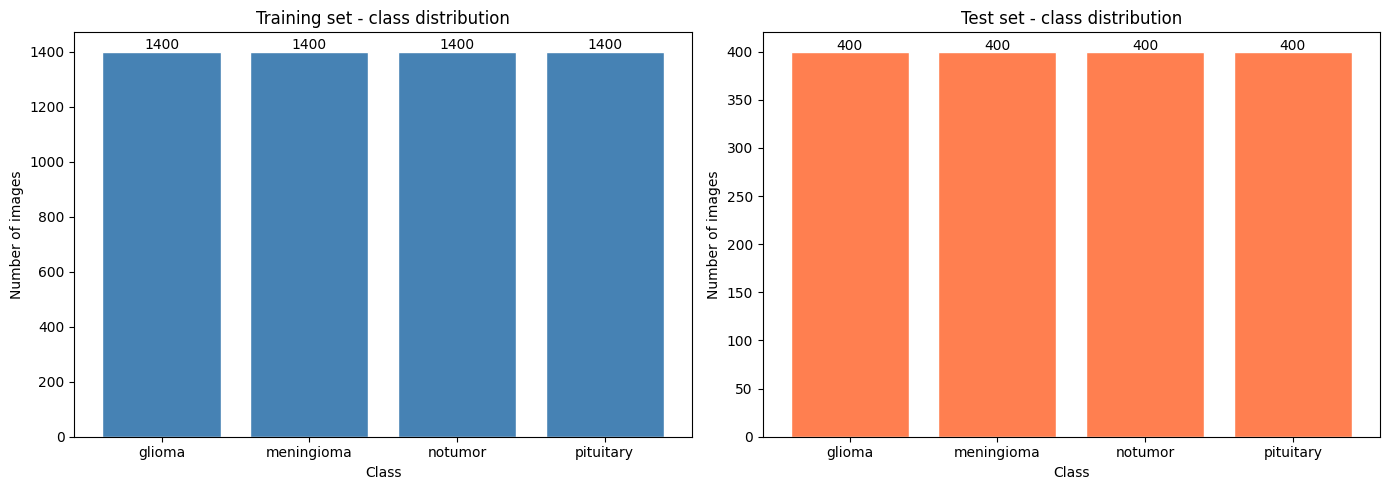

In [ ]:
# --- Plot class distribution and sample images --------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart - class balance
axes[0].bar(train_counts.keys(), train_counts.values(), color='steelblue', edgecolor='white')
axes[0].set_title('Training set - class distribution')
axes[0].set_ylabel('Number of images')
axes[0].set_xlabel('Class')
for i, (cls, n) in enumerate(train_counts.items()):
    axes[0].text(i, n + 10, str(n), ha='center', fontsize=10)

# Bar chart - test set
axes[1].bar(test_counts.keys(), test_counts.values(), color='coral', edgecolor='white')
axes[1].set_title('Test set - class distribution')
axes[1].set_ylabel('Number of images')
axes[1].set_xlabel('Class')
for i, (cls, n) in enumerate(test_counts.items()):
    axes[1].text(i, n + 2, str(n), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

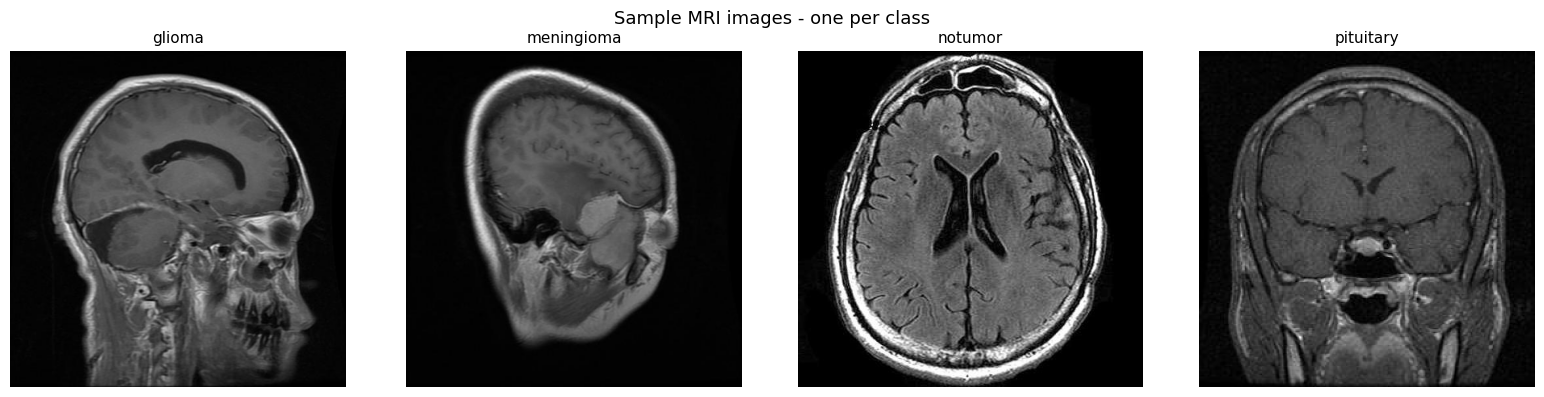

In [ ]:
# --- Display one sample image per class --------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Sample MRI images - one per class', fontsize=13)

for ax, cls in zip(axes, sorted(train_counts.keys())):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    sample  = random.choice(os.listdir(cls_dir))
    img     = Image.open(os.path.join(cls_dir, sample)).convert('RGB')
    ax.imshow(img, cmap='gray')
    ax.set_title(cls, fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

### C2 - Preprocessing and Augmentation

Training transform applies augmentation to improve generalisation:
  - Random horizontal flip: MRI tumours can appear on either hemisphere
  - Random rotation (±15°): accounts for variation in patient positioning
  - Colour jitter: simulates scanner intensity variation
  
Validation/test transforms apply only normalisation - no augmentation,
as we want a deterministic evaluation.

Normalisation uses ImageNet mean and std because our backbones
(ResNet18, EfficientNetB0) were pre-trained on ImageNet.

In [10]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print('Transforms defined.')

Transforms defined.


### C3 - DataLoaders

The dataset provides a pre-defined train/test split.

We cut out 15% of the training set as a validation set.

Validation is used for monitoring training, selecting the best model weights, and tuning design choices.

The test set is touched only once for final evaluation.

In [11]:
# Load full training set (no augmentation yet - applied per-split below)
full_train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transform)
test_dataset       = datasets.ImageFolder(root=TEST_DIR,  transform=val_test_transform)

# Compute split sizes
n_total = len(full_train_dataset)
n_val   = int(n_total * VAL_SPLIT)
n_train = n_total - n_val

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED)
)

# Apply val/test transform to the validation split
val_dataset.dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=val_test_transform)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Training samples   : {n_train}')
print(f'Validation samples : {n_val}')
print(f'Test samples       : {len(test_dataset)}')
print(f'Batches per epoch  : {len(train_loader)}')
print(f'Class index map    : {full_train_dataset.class_to_idx}')

Training samples   : 4760
Validation samples : 840
Test samples       : 1600
Batches per epoch  : 149
Class index map    : {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


## Section D - Traditional ML Baseline: SVM

### HOG Feature Extraction
SVMs cannot process raw image tensors directly, since they require fixed-length
feature vectors. We use Histogram of Oriented Gradients (HOG), a hand-crafted
descriptor that captures edge direction distributions across image patches.

This is central to the ML vs DL comparison: the SVM relies on *manually
engineered* features, whereas the CNNs learn their own representations.

Images are resized to 64x64 for HOG (smaller than DL input - SVM is
computationally sensitive to input dimensionality).

In [12]:
from skimage.feature import hog

HOG_SIZE = 64  # Resize to 64x64 before HOG extraction

def extract_hog_features(data_dir):
    """Load all images from an ImageFolder-style directory and extract HOG features."""
    features, labels = [], []
    class_list = sorted(os.listdir(data_dir))
    label_map  = {cls: i for i, cls in enumerate(class_list)}

    for cls in class_list:
        cls_path = os.path.join(data_dir, cls)
        if not os.path.isdir(cls_path):
            continue
        for fname in tqdm(os.listdir(cls_path), desc=f'HOG: {cls}'):
            fpath = os.path.join(cls_path, fname)
            try:
                img = Image.open(fpath).convert('L')
                img = img.resize((HOG_SIZE, HOG_SIZE))
                img_arr = np.array(img)
                feat = hog(
                    img_arr,
                    orientations=9,
                    pixels_per_cell=(8, 8),
                    cells_per_block=(2, 2),
                    block_norm='L2-Hys'
                )
                features.append(feat)
                labels.append(label_map[cls])
            except Exception:
                pass  # skip corrupt images

    return np.array(features), np.array(labels)

print('Extracting HOG features from training set...')
X_train_hog, y_train_hog = extract_hog_features(TRAIN_DIR)

print('\nExtracting HOG features from test set...')
X_test_hog, y_test_hog = extract_hog_features(TEST_DIR)

print(f'\nHOG feature vector length : {X_train_hog.shape[1]}')
print(f'Training samples          : {X_train_hog.shape[0]}')
print(f'Test samples              : {X_test_hog.shape[0]}')

Extracting HOG features from training set...


HOG: pituitary: 100%|██████████| 1400/1400 [00:02<00:00, 484.69it/s]



Extracting HOG features from test set...


HOG: pituitary: 100%|██████████| 400/400 [00:00<00:00, 522.37it/s]


HOG feature vector length : 1764
Training samples          : 5600
Test samples              : 1600


### Dimensionality Reduction + SVM Training

HOG produces ~1764-dimensional vectors. PCA reduces this to 150 components
while retaining most variance, which speeds up SVM training considerably.

We use an RBF (radial basis function) kernel SVM, appropriate for
non-linearly separable image feature data.
GridSearchCV finds the best C (regularisation) and gamma (kernel width).

In [ ]:
# Standardise features (SVM is sensitive to scale)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_hog)
X_test_scaled  = scaler.transform(X_test_hog)

# PCA dimensionality reduction
PCA_COMPONENTS = 150
pca = PCA(n_components=PCA_COMPONENTS, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

explained_var = pca.explained_variance_ratio_.sum()
print(f'PCA: {PCA_COMPONENTS} components explain {explained_var:.1%} of variance')

# Grid search over C and gamma
print('\nRunning GridSearchCV ...')
param_grid = {
    'C'    : [0.1, 1, 10],
    'gamma': ['scale', 0.01],
}
svm_grid = GridSearchCV(
    SVC(kernel='rbf', class_weight='balanced', random_state=SEED),
    param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
svm_grid.fit(X_train_pca, y_train_hog)

best_svm = svm_grid.best_estimator_
print(f'\nBest params : {svm_grid.best_params_}')
print(f'Best CV F1  : {svm_grid.best_score_:.4f}')

PCA: 150 components explain 75.9% of variance

Running GridSearchCV (this may take a few minutes)...
Fitting 3 folds for each of 6 candidates, totalling 18 fits

Best params : {'C': 10, 'gamma': 'scale'}
Best CV F1  : 0.9364


### SVM Evaluation

SVM Test Results
Accuracy : 0.9100
Macro F1 : 0.9076

              precision    recall  f1-score   support

      glioma       0.92      0.76      0.83       400
  meningioma       0.89      0.90      0.89       400
     notumor       0.88      1.00      0.94       400
   pituitary       0.95      0.98      0.97       400

    accuracy                           0.91      1600
   macro avg       0.91      0.91      0.91      1600
weighted avg       0.91      0.91      0.91      1600



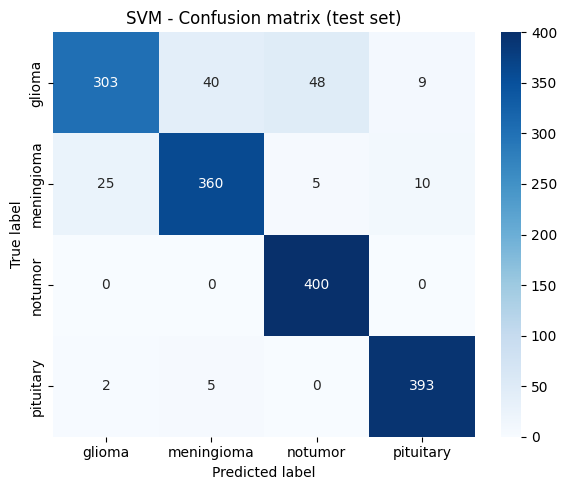

In [ ]:
y_pred_svm = best_svm.predict(X_test_pca)

svm_accuracy = accuracy_score(y_test_hog, y_pred_svm)
svm_f1       = f1_score(y_test_hog, y_pred_svm, average='macro')

print('SVM Test Results')
print('=' * 40)
print(f'Accuracy : {svm_accuracy:.4f}')
print(f'Macro F1 : {svm_f1:.4f}')
print()
print(classification_report(y_test_hog, y_pred_svm,
                             target_names=CLASS_NAMES))

# Confusion matrix
cm_svm = confusion_matrix(y_test_hog, y_pred_svm)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('SVM - Confusion matrix (test set)')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cm_svm.png', dpi=150, bbox_inches='tight')
plt.show()

# Store for later comparison
results = {
    'SVM (HOG + PCA)': {'accuracy': svm_accuracy, 'f1': svm_f1,
                         'params': 'N/A', 'train_time': 'see GridSearch'}
}

## Section E - Deep Learning Models

### Shared training infrastructure
A single reusable `train_model()` function is used for all three DL models.


It trains a PyTorch model and returns per-epoch loss and accuracy histories.
```data
Args:
- model       : PyTorch model (already on DEVICE)
- train_loader: DataLoader for training data
- val_loader  : DataLoader for validation data
- criterion   : Loss function
- optimizer   : Optimiser
- scheduler   : LR scheduler
- num_epochs  : Number of training epochs
- model_name  : String label for progress output
```
Returns:
        history dict with train/val loss and accuracy lists

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer,
                scheduler=None, num_epochs=10, model_name='model'):
    """
    Train a PyTorch model and return per-epoch loss and accuracy histories.

    Args:
        model       : PyTorch model (already on DEVICE)
        train_loader: DataLoader for training data
        val_loader  : DataLoader for validation data
        criterion   : Loss function
        optimizer   : Optimiser
        scheduler   : LR scheduler
        num_epochs  : Number of training epochs
        model_name  : String label for progress output

    Returns:
        history dict with train/val loss and accuracy lists
    """
    history = {'train_loss': [], 'val_loss': [],
               'train_acc': [],  'val_acc': []}
    best_val_acc = 0.0
    best_weights = None

    for epoch in range(num_epochs):
        # --- Training phase ----------------------------------------------
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in tqdm(train_loader,
                                   desc=f'{model_name} Epoch {epoch+1}/{num_epochs}',
                                   leave=False):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted  = torch.max(outputs, 1)
            total        += labels.size(0)
            correct      += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_acc  = correct / total

        # --- Validation phase ----------------------------------------------
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs  = model(images)
                loss     = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total   += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_loss / val_total
        val_acc  = val_correct / val_total

        if scheduler:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        # Save best weights
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f'  Epoch {epoch+1:02d} | '
              f'train loss {train_loss:.4f} acc {train_acc:.4f} | '
              f'val loss {val_loss:.4f} acc {val_acc:.4f}')

    # Restore best weights
    if best_weights:
        model.load_state_dict(best_weights)
        print(f'\nBest val accuracy: {best_val_acc:.4f} - weights restored.')

    return history

def evaluate_model(model, test_loader, model_name='model'):
    """Evaluate a trained model on the test set. Returns accuracy, F1, and predictions."""
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(DEVICE)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='macro')
    print(f'\n{model_name} - Test Accuracy: {acc:.4f} | Macro F1: {f1:.4f}')
    print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))
    return acc, f1, all_preds, all_labels

def plot_history(history, model_name):
    """Plot training and validation loss/accuracy curves."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history['train_loss']) + 1)

    axes[0].plot(epochs, history['train_loss'], label='Train')
    axes[0].plot(epochs, history['val_loss'],   label='Val')
    axes[0].set_title(f'{model_name} - Loss')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend()

    axes[1].plot(epochs, history['train_acc'], label='Train')
    axes[1].plot(epochs, history['val_acc'],   label='Val')
    axes[1].set_title(f'{model_name} - Accuracy')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend()

    plt.tight_layout()
    fname = model_name.lower().replace(' ', '_')
    save_path = RESULTS_DIR / f'curves_{fname}.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

def plot_confusion_matrix(labels, preds, model_name):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f'{model_name} - Confusion matrix (test set)')
    plt.ylabel('True label'); plt.xlabel('Predicted label')
    plt.tight_layout()
    fname = model_name.lower().replace(' ', '_')
    save_path = RESULTS_DIR / f'cm_{fname}.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

# Standard cross-entropy loss - shared across all DL models
criterion = nn.CrossEntropyLoss()
print('Shared utilities ready.')

Shared utilities ready.


### E1 - Custom CNN (trained from scratch)

A 4-block convolutional network trained entirely from scratch.
Purpose: establish a DL baseline and demonstrate understanding of CNN
fundamentals. Expected to underperform transfer learning models
due to limited training data (~5,900 images).

**Architecture:**

  4 x [Conv2d → BatchNorm → ReLU → MaxPool]

  Adaptive average pooling → Flatten → FC(256) → Dropout → FC(4)

In [16]:
class BrainTumourCNN(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 3 → 32 channels
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 224 → 112

            # Block 2: 32 → 64 channels
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 112 → 56

            # Block 3: 64 → 128 channels
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 56 → 28

            # Block 4: 128 → 256 channels
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 28 → 14
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),   # → 256 x 1 x 1
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

cnn_model = BrainTumourCNN(num_classes=NUM_CLASSES).to(DEVICE)
cnn_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f'Custom CNN trainable parameters: {cnn_params:,}')

Custom CNN trainable parameters: 456,196


### Train custom CNN

  Epoch 01 | train loss 0.8496 acc 0.6489 | val loss 2.1633 acc 0.4262


  Epoch 02 | train loss 0.6886 acc 0.7303 | val loss 1.1503 acc 0.5262


  Epoch 03 | train loss 0.5869 acc 0.7651 | val loss 0.8246 acc 0.6679


  Epoch 04 | train loss 0.5121 acc 0.8017 | val loss 0.5086 acc 0.7774


  Epoch 05 | train loss 0.5049 acc 0.8105 | val loss 1.9253 acc 0.5345


...

  Epoch 56 | train loss 0.1514 acc 0.9443 | val loss 0.1707 acc 0.9333


  Epoch 57 | train loss 0.1419 acc 0.9502 | val loss 0.1673 acc 0.9440


  Epoch 58 | train loss 0.1501 acc 0.9437 | val loss 0.1790 acc 0.9321


  Epoch 59 | train loss 0.1448 acc 0.9492 | val loss 0.1706 acc 0.9464


  Epoch 60 | train loss 0.1495 acc 0.9460 | val loss 0.1886 acc 0.9333

Best val accuracy: 0.9464 - weights restored.


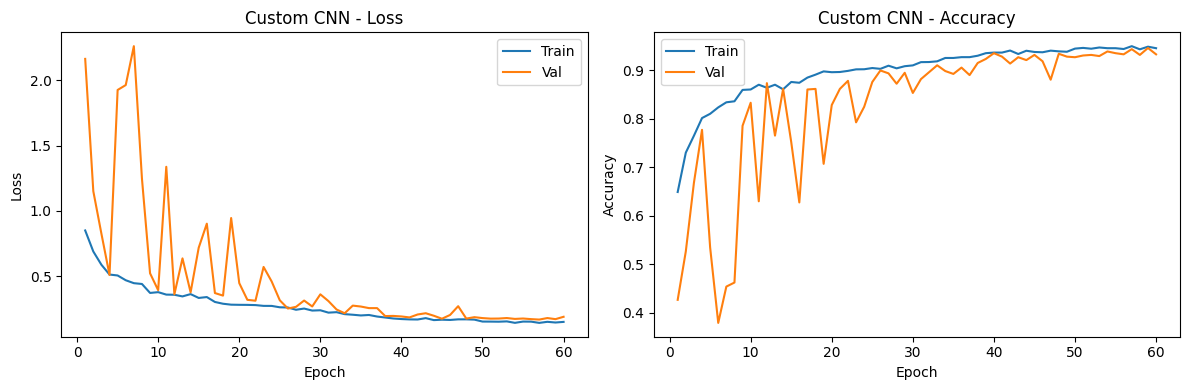


Custom CNN - Test Accuracy: 0.8919 | Macro F1: 0.8881
              precision    recall  f1-score   support

      glioma       0.99      0.70      0.82       400
  meningioma       0.83      0.88      0.85       400
     notumor       0.85      1.00      0.92       400
   pituitary       0.93      0.99      0.96       400

    accuracy                           0.89      1600
   macro avg       0.90      0.89      0.89      1600
weighted avg       0.90      0.89      0.89      1600



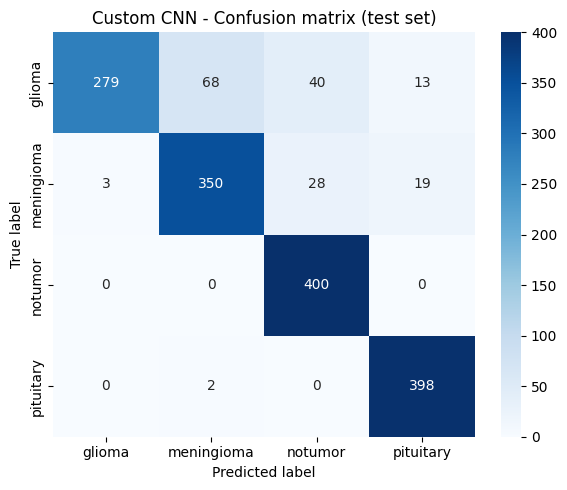

In [ ]:
cnn_optimizer = optim.Adam(
    cnn_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4

)
cnn_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    cnn_optimizer,
    patience=3, 
    factor=0.5
)

cnn_start = time.time()

cnn_history = train_model(
    cnn_model, 
    train_loader, 
    val_loader,
    criterion, 
    cnn_optimizer, 
    cnn_scheduler,
    num_epochs=NUM_EPOCHS_CNN, 
    model_name='Custom CNN'
)

cnn_time = time.time() - cnn_start

plot_history(cnn_history, 'Custom CNN')
cnn_acc, cnn_f1, cnn_preds, cnn_labels = evaluate_model(cnn_model, test_loader, 'Custom CNN')
plot_confusion_matrix(cnn_labels, cnn_preds, 'Custom CNN')

results['Custom CNN'] = {
    'accuracy': cnn_acc, 'f1': cnn_f1,
    'params': cnn_params, 'train_time': f'{cnn_time/60:.1f} min'
}

### E2 - ResNet18 (transfer learning)

ResNet18 is pre-trained on ImageNet and is used here as a transfer learning model. The original final layer is replaced with a new classification head for the four MRI classes.

**Training strategy**

Full mode:
- Phase 1 (20 epochs): freeze the ResNet18 backbone and train only the new classification head at `lr=1e-3`.
- Phase 2 (40 epochs): unfreeze `layer4` and fine-tune the higher-level features at `lr=1e-5`.

Demo mode:
- Phase 1 (5 epochs): freeze the ResNet18 backbone and train only the new classification head at `lr=1e-3`.
- Phase 2 (15 epochs): unfreeze `layer4` and fine-tune the higher-level features at `lr=1e-5`.

**Design decisions**
- The backbone is frozen first so the new classifier can learn the MRI classes without immediately changing the pre-trained features.
- `layer4` is unfrozen in phase 2 because later layers are more task-specific, while earlier layers usually capture more general features such as edges and textures.
- A smaller learning rate is used during fine-tuning to reduce the risk of overwriting useful pre-trained features.
- Dropout is included in the classification head to reduce overfitting.

ResNet18 trainable params (phase 1): 132,356

--- ResNet18 Phase 1: head-only training ---


  Epoch 01 | train loss 0.6816 acc 0.7296 | val loss 0.5074 acc 0.8060


  Epoch 02 | train loss 0.5229 acc 0.7964 | val loss 0.4134 acc 0.8560


  Epoch 03 | train loss 0.4985 acc 0.8118 | val loss 0.4237 acc 0.8536


  Epoch 04 | train loss 0.4617 acc 0.8250 | val loss 0.4217 acc 0.8429


...

  Epoch 36 | train loss 0.0363 acc 0.9872 | val loss 0.0877 acc 0.9750


  Epoch 37 | train loss 0.0342 acc 0.9895 | val loss 0.0768 acc 0.9750


  Epoch 38 | train loss 0.0361 acc 0.9878 | val loss 0.0886 acc 0.9714


  Epoch 39 | train loss 0.0310 acc 0.9910 | val loss 0.0867 acc 0.9702


  Epoch 40 | train loss 0.0311 acc 0.9895 | val loss 0.0829 acc 0.9738

Best val accuracy: 0.9762 - weights restored.


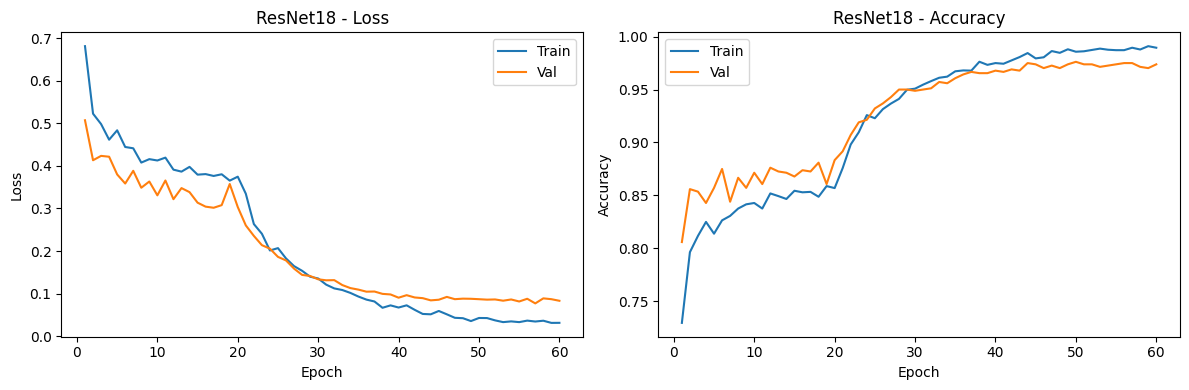


ResNet18 - Test Accuracy: 0.9400 | Macro F1: 0.9382
              precision    recall  f1-score   support

      glioma       0.99      0.79      0.88       400
  meningioma       0.89      0.98      0.93       400
     notumor       0.91      1.00      0.95       400
   pituitary       0.99      0.99      0.99       400

    accuracy                           0.94      1600
   macro avg       0.94      0.94      0.94      1600
weighted avg       0.94      0.94      0.94      1600



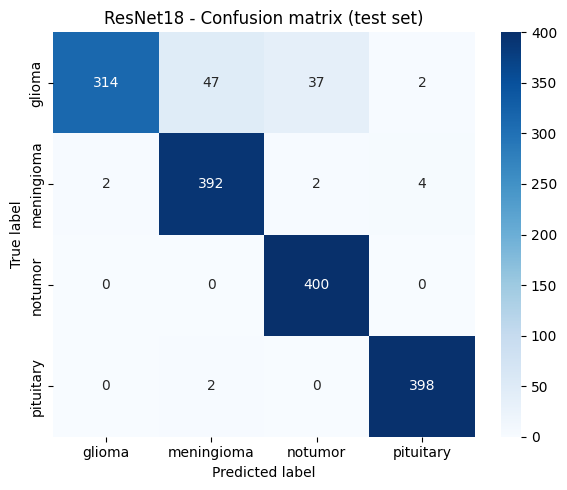

In [18]:
resnet = models.resnet18(weights='IMAGENET1K_V1')

# Freeze all backbone layers
for param in resnet.parameters():
    param.requires_grad = False

# Replace the final fully-connected layer
in_features = resnet.fc.in_features
resnet.fc = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.2),
    nn.Linear(256, NUM_CLASSES)
)

resnet = resnet.to(DEVICE)

resnet_params_phase1 = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
print(f'ResNet18 trainable params (phase 1): {resnet_params_phase1:,}')

# --- Phase 1: head only -------------------------------------------------------
opt_r1 = optim.Adam(resnet.fc.parameters(), lr=1e-3)
sch_r1 = optim.lr_scheduler.ReduceLROnPlateau(opt_r1, patience=3, factor=0.5)

resnet_start = time.time()
print('\n--- ResNet18 Phase 1: head-only training ---')
history_r1 = train_model(
    resnet, train_loader, val_loader,
    criterion, opt_r1, sch_r1,
    num_epochs=NUM_EPOCHS_PHASE1, model_name='ResNet18-P1'
)

# --- Phase 2: unfreeze layer4 and fine-tune ------------------------------------
for param in resnet.layer4.parameters():
    param.requires_grad = True

resnet_params_phase2 = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
print(f'ResNet18 trainable params (phase 2): {resnet_params_phase2:,}')

opt_r2 = optim.Adam(
    filter(lambda p: p.requires_grad, resnet.parameters()), lr=1e-5
)
sch_r2 = optim.lr_scheduler.ReduceLROnPlateau(opt_r2, patience=3, factor=0.5)

print('\n--- ResNet18 Phase 2: fine-tuning ---')
history_r2 = train_model(
    resnet, train_loader, val_loader,
    criterion, opt_r2, sch_r2,
    num_epochs=NUM_EPOCHS_PHASE2, model_name='ResNet18-P2'
)
resnet_time = time.time() - resnet_start

# Combine phase histories for plotting
resnet_history = {k: history_r1[k] + history_r2[k] for k in history_r1}
plot_history(resnet_history, 'ResNet18')
rn_acc, rn_f1, rn_preds, rn_labels = evaluate_model(resnet, test_loader, 'ResNet18')
plot_confusion_matrix(rn_labels, rn_preds, 'ResNet18')

results['ResNet18'] = {
    'accuracy': rn_acc, 'f1': rn_f1,
    'params': resnet_params_phase2, 'train_time': f'{resnet_time/60:.1f} min'
}

### E3 - EfficientNetB0 (transfer learning)

EfficientNetB0 uses compound scaling, where width, depth, and input resolution are scaled together. This makes it more parameter-efficient than ResNet18, which is useful when both classification performance and computational efficiency matter.

The model uses the same two-phase transfer learning strategy as ResNet18 for consistency.

**Training strategy**

Full mode:
- Phase 1 (20 epochs): freeze the EfficientNetB0 backbone and train only the new classifier head at `lr=1e-3`.
- Phase 2 (40 epochs): unfreeze the last five feature blocks and fine-tune them at `lr=1e-5`.

Demo mode:
- Phase 1 (5 epochs): freeze the EfficientNetB0 backbone and train only the new classifier head at `lr=1e-3`.
- Phase 2 (15 epochs): unfreeze the last five feature blocks and fine-tune them at `lr=1e-5`.

**Design decisions**
- The original classifier is replaced with a new four-class head for the MRI task.
- The backbone is frozen first to protect the pre-trained features while the new classifier learns.
- The last five feature blocks are unfrozen because they contain higher-level features that can adapt to tumour-related patterns.
- Stronger augmentation is used to improve generalisation to unseen scans.
- Label smoothing is used to reduce overconfident predictions.
- AdamW and `ReduceLROnPlateau` are used during fine-tuning to improve regularisation and adjust the learning rate when validation loss stops improving.

EfficientNetB0 trainable params (phase 1): 5,124

--- EfficientNetB0 Phase 1: head-only training ---


  Epoch 01 | train loss 0.8587 acc 0.7527 | val loss 0.7505 acc 0.8179


  Epoch 02 | train loss 0.7239 acc 0.8193 | val loss 0.7083 acc 0.8321


  Epoch 03 | train loss 0.6948 acc 0.8387 | val loss 0.6843 acc 0.8548


  Epoch 04 | train loss 0.6944 acc 0.8300 | val loss 0.6758 acc 0.8524


...

  Epoch 36 | train loss 0.4407 acc 0.9710 | val loss 0.4170 acc 0.9833


  Epoch 37 | train loss 0.4357 acc 0.9744 | val loss 0.4176 acc 0.9798


  Epoch 38 | train loss 0.4360 acc 0.9744 | val loss 0.4172 acc 0.9833


  Epoch 39 | train loss 0.4324 acc 0.9742 | val loss 0.4126 acc 0.9833


  Epoch 40 | train loss 0.4269 acc 0.9765 | val loss 0.4101 acc 0.9845

Best val accuracy: 0.9845 - weights restored.


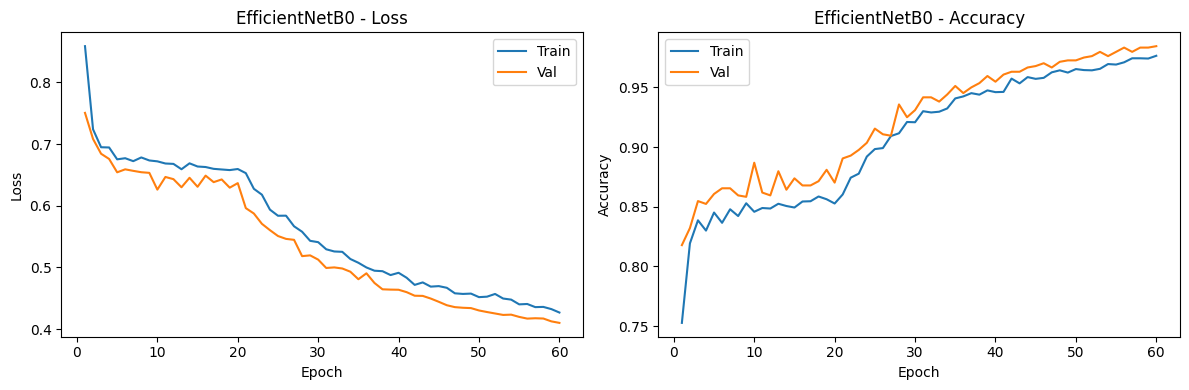


EfficientNetB0 - Test Accuracy: 0.9419 | Macro F1: 0.9405
              precision    recall  f1-score   support

      glioma       0.99      0.80      0.88       400
  meningioma       0.88      0.99      0.93       400
     notumor       0.92      1.00      0.96       400
   pituitary       0.99      0.98      0.99       400

    accuracy                           0.94      1600
   macro avg       0.95      0.94      0.94      1600
weighted avg       0.95      0.94      0.94      1600



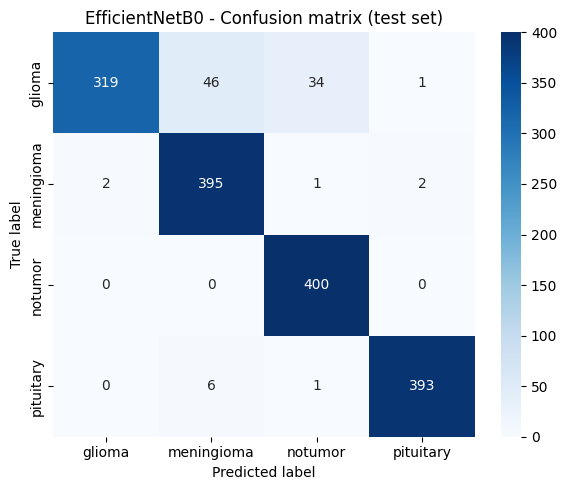

In [ ]:
# Stronger augmentation to improve generalisation on unseen scans
# Vertical flip and affine transforms add variation beyond the standard pipeline
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# DataLoaders with updated transform
# Val and test keep original transform - no augmentation on evaluation data
full_train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transform)
train_dataset, val_dataset = random_split(
    full_train_dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED)
)
val_dataset.dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

# Label smoothing targets ~0.9 instead of 1.0, reducing overconfidence
# and improving generalisation by discouraging overly confident outputs
criterion_smooth = nn.CrossEntropyLoss(label_smoothing=0.1)

# --- Model ----------------------------------------------------------------------
# Load EfficientNetB0 pre-trained on ImageNet, freeze all backbone weights
# Freezing protects learned features from being overwritten by the random head
effnet = models.efficientnet_b0(weights='IMAGENET1K_V1')

for param in effnet.parameters():
    param.requires_grad = False

# Single linear head - simpler than two-layer alternative, better generalisation
# since backbone features are already rich enough for classification
in_features_eff = effnet.classifier[1].in_features
effnet.classifier = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(in_features_eff, NUM_CLASSES)
)
effnet = effnet.to(DEVICE)

eff_params_phase1 = sum(p.numel() for p in effnet.parameters() if p.requires_grad)
print(f'EfficientNetB0 trainable params (phase 1): {eff_params_phase1:,}')

# --- Phase 1: train head only, backbone frozen ---------------------------------
# Adam at lr=1e-3 stabilises the head before any backbone updates
opt_e1 = optim.Adam(effnet.classifier.parameters(), lr=1e-3)
sch_e1 = optim.lr_scheduler.ReduceLROnPlateau(opt_e1, patience=3, factor=0.5)

eff_start = time.time()
print('\n--- EfficientNetB0 Phase 1: head-only training ---')
history_e1 = train_model(
    effnet, train_loader, val_loader,
    criterion_smooth, opt_e1, sch_e1,
    num_epochs=NUM_EPOCHS_PHASE1, model_name='EffNetB0-P1'
)

# --- Phase 2: unfreeze last 5 MBConv blocks ------------------------------------
# Blocks 4-8 have high-level semantic features most relevant to MRI patterns
# Early blocks stay frozen - low-level features generalise across domains
for block in list(effnet.features.children())[-5:]:
    for param in block.parameters():
        param.requires_grad = True

eff_params_phase2 = sum(p.numel() for p in effnet.parameters() if p.requires_grad)
print(f'EfficientNetB0 trainable params (phase 2): {eff_params_phase2:,}')

# AdamW with weight decay for regularisation during fine-tuning
# lr=1e-5 avoids catastrophic forgetting of ImageNet features
opt_e2 = optim.AdamW(
    filter(lambda p: p.requires_grad, effnet.parameters()),
    lr=1e-5, weight_decay=1e-4
)

sch_e2 = optim.lr_scheduler.ReduceLROnPlateau(opt_e2, patience=3, factor=0.5)

print('\n--- EfficientNetB0 Phase 2: fine-tuning ---')
history_e2 = train_model(
    effnet, train_loader, val_loader,
    criterion_smooth, opt_e2, sch_e2,
    num_epochs=NUM_EPOCHS_PHASE2, model_name='EffNetB0-P2'
)
eff_time = time.time() - eff_start

effnet_history = {k: history_e1[k] + history_e2[k] for k in history_e1}
plot_history(effnet_history, 'EfficientNetB0')
eff_acc, eff_f1, eff_preds, eff_labels = evaluate_model(effnet, test_loader, 'EfficientNetB0')
plot_confusion_matrix(eff_labels, eff_preds, 'EfficientNetB0')

results['EfficientNetB0'] = {
    'accuracy': eff_acc, 'f1': eff_f1,
    'params': eff_params_phase2, 'train_time': f'{eff_time/60:.1f} min'
}

## Section F - Model Comparison

Summary of all four models in a table and bar chart.

=== Model Comparison Summary ===
          Model Accuracy Macro F1 Trainable Params     Train Time
SVM (HOG + PCA)   0.9100   0.9076              N/A see GridSearch
     Custom CNN   0.8919   0.8881           456196       12.9 min
       ResNet18   0.9400   0.9382          8526084       11.9 min
 EfficientNetB0   0.9419   0.9405          3946942       14.7 min


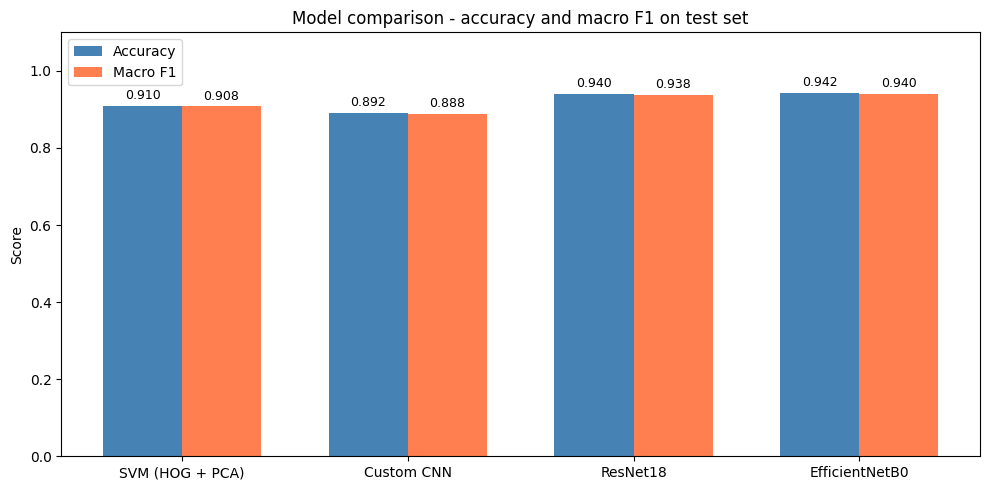

In [ ]:
import pandas as pd

df_results = pd.DataFrame(results).T.reset_index()
df_results.columns = ['Model', 'Accuracy', 'Macro F1', 'Trainable Params', 'Train Time']
df_results['Accuracy'] = df_results['Accuracy'].apply(lambda x: f'{float(x):.4f}')
df_results['Macro F1'] = df_results['Macro F1'].apply(lambda x: f'{float(x):.4f}')

print('=== Model Comparison Summary ===')
print(df_results.to_string(index=False))

# Bar chart - accuracy and F1 side by side
model_names = list(results.keys())
accs = [float(results[m]['accuracy']) for m in model_names]
f1s  = [float(results[m]['f1'])       for m in model_names]

x = range(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar([i - width/2 for i in x], accs, width, label='Accuracy', color='steelblue')
bars2 = ax.bar([i + width/2 for i in x], f1s,  width, label='Macro F1', color='coral')

ax.set_xticks(list(x))
ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model comparison - accuracy and macro F1 on test set')
ax.legend()

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Section G - Interpretability: Grad-CAM

Gradient-weighted Class Activation Mapping (Grad-CAM) highlights the image
regions that most influenced the model's prediction.
For brain tumour classification, we want to verify the model attends to
tumour regions rather than background artefacts - this is clinically important
and directly supports the ethics discussion in the report (LO2).

We apply Grad-CAM to EfficientNetB0 (our best model).

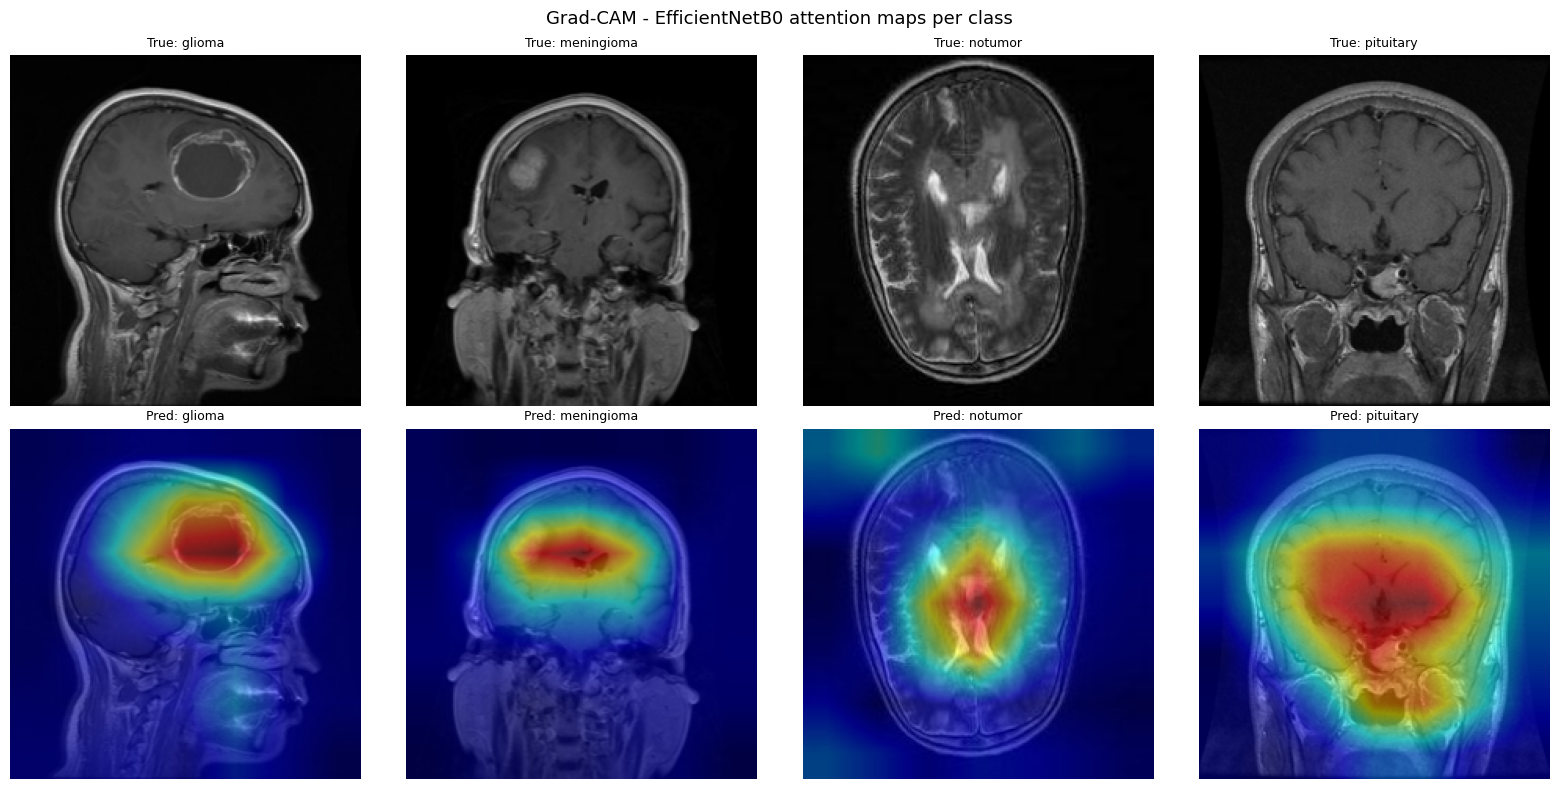

Grad-CAM complete. Red/warm regions indicate high model attention.


In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Target the last convolutional block in EfficientNetB0
target_layer = [effnet.features[-1]]
cam = GradCAM(model=effnet, target_layers=target_layer)

# Visualise Grad-CAM for one sample from each class
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Grad-CAM - EfficientNetB0 attention maps per class', fontsize=13)

for col, cls in enumerate(sorted(os.listdir(TEST_DIR))):
    cls_dir = os.path.join(TEST_DIR, cls)
    sample  = random.choice(os.listdir(cls_dir))
    fpath   = os.path.join(cls_dir, sample)

    # Original image (for display)
    orig_img = Image.open(fpath).convert('RGB').resize((IMAGE_SIZE, IMAGE_SIZE))
    orig_arr = np.array(orig_img) / 255.0

    # Preprocessed tensor (for model)
    tensor = val_test_transform(orig_img).unsqueeze(0).to(DEVICE)

    # Get predicted class
    with torch.no_grad():
        output = effnet(tensor)
        pred_class = torch.argmax(output, dim=1).item()

    # Compute Grad-CAM
    grayscale_cam = cam(input_tensor=tensor,
                        targets=[ClassifierOutputTarget(pred_class)])
    cam_image = show_cam_on_image(orig_arr.astype(np.float32),
                                   grayscale_cam[0], use_rgb=True)

    # Row 0: original MRI
    axes[0][col].imshow(orig_img)
    axes[0][col].set_title(f'True: {cls}', fontsize=9)
    axes[0][col].axis('off')

    # Row 1: Grad-CAM overlay
    axes[1][col].imshow(cam_image)
    axes[1][col].set_title(f'Pred: {CLASS_NAMES[pred_class]}', fontsize=9)
    axes[1][col].axis('off')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'gradcam_visualisation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grad-CAM complete. Red/warm regions indicate high model attention.')

### Extended Interpretability
Per-class accuracy, confidence distributions, and ROC curves to complement the Grad-CAM visualisation

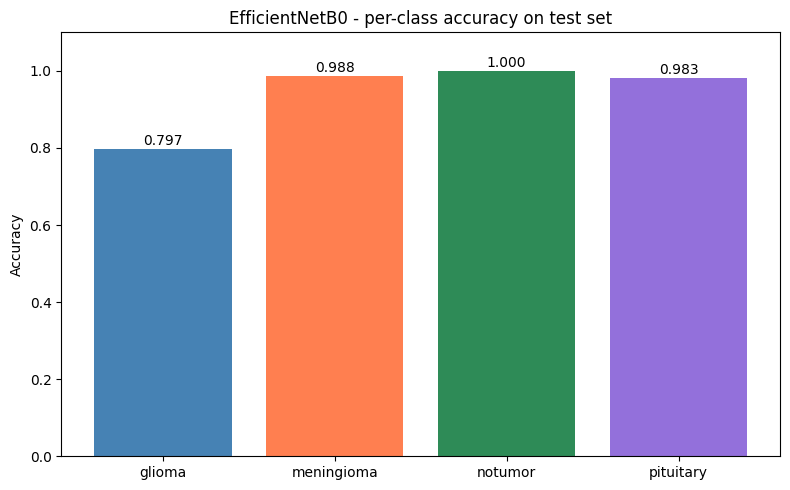

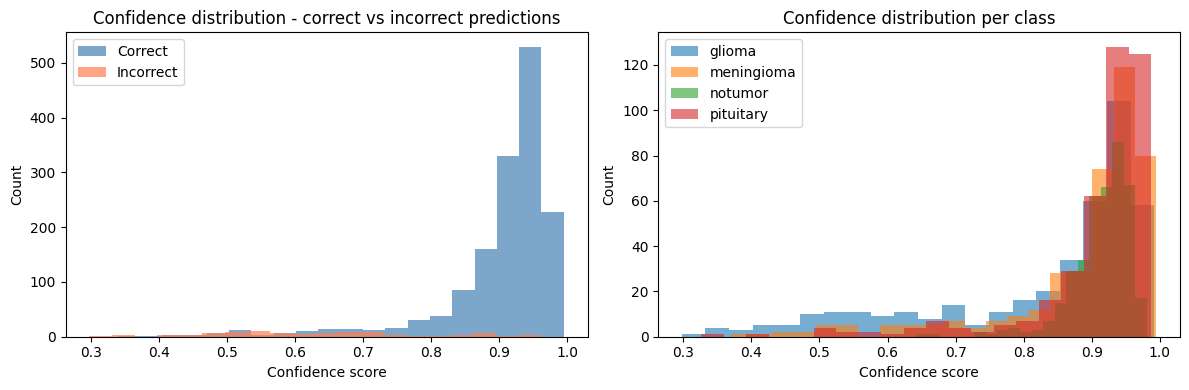

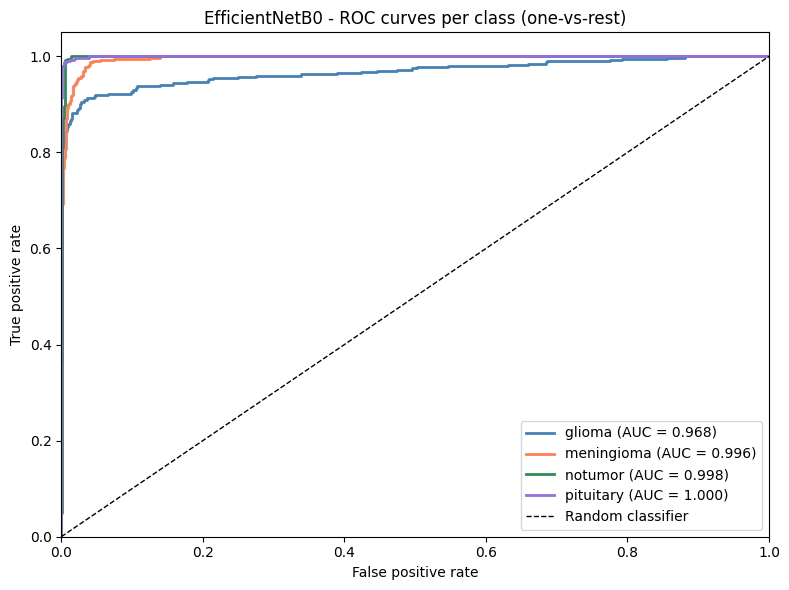

AUC scores per class:
  glioma          AUC = 0.9679
  meningioma      AUC = 0.9955
  notumor         AUC = 0.9981
  pituitary       AUC = 0.9997


In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import torch.nn.functional as F

# Collect predictions and confidence scores from EfficientNetB0
effnet.eval()
all_probs, all_preds, all_labels = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = effnet(images)
        probs = F.softmax(outputs, dim=1)  # convert logits to probabilities
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(probs.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs  = np.array(all_probs)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# --- Per-class accuracy bar chart ---------------------------------------
per_class_acc = []
for i, cls in enumerate(CLASS_NAMES):
    mask = all_labels == i
    acc  = (all_preds[mask] == all_labels[mask]).mean()
    per_class_acc.append(acc)

plt.figure(figsize=(8, 5))
bars = plt.bar(CLASS_NAMES, per_class_acc, color=['steelblue', 'coral', 'seagreen', 'mediumpurple'])
plt.ylim(0, 1.1)
plt.ylabel('Accuracy')
plt.title('EfficientNetB0 - per-class accuracy on test set')
for bar, acc in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Confidence score distribution ----------------------------------------
# Shows how confident the model is on correct vs incorrect predictions.
max_probs  = all_probs.max(axis=1)        # confidence = max class probability
correct    = all_preds == all_labels

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(max_probs[correct],   bins=20, color='steelblue', alpha=0.7, label='Correct')
axes[0].hist(max_probs[~correct],  bins=20, color='coral',     alpha=0.7, label='Incorrect')
axes[0].set_xlabel('Confidence score')
axes[0].set_ylabel('Count')
axes[0].set_title('Confidence distribution - correct vs incorrect predictions')
axes[0].legend()

# Per-class confidence
for i, cls in enumerate(CLASS_NAMES):
    mask = all_labels == i
    axes[1].hist(max_probs[mask], bins=20, alpha=0.6, label=cls)
axes[1].set_xlabel('Confidence score')
axes[1].set_ylabel('Count')
axes[1].set_title('Confidence distribution per class')
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# --- ROC curves per class (one-vs-rest) --------------------------------------
# Binarise labels for one-vs-rest ROC calculation
labels_bin = label_binarize(all_labels, classes=[0, 1, 2, 3])

plt.figure(figsize=(8, 6))
colors = ['steelblue', 'coral', 'seagreen', 'mediumpurple']

for i, (cls, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], all_probs[:, i])
    roc_auc     = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{cls} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('EfficientNetB0 - ROC curves per class (one-vs-rest)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Print AUC summary
print('AUC scores per class:')
for i, cls in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], all_probs[:, i])
    print(f'  {cls:<15} AUC = {auc(fpr, tpr):.4f}')

## Section H - Conclusions

In [23]:
print('=== Final Results Summary ===')
print()

if DEMO_MODE:
    print('NOTE: Demo mode was enabled.')
    print('These results are only for a quick execution check and do not match the reported results.')
    print()
    
best_model = max(results, key=lambda m: results[m]['f1'])
print(f'Best performing model : {best_model}')
print(f'  Test accuracy       : {results[best_model]["accuracy"]:.4f}')
print(f'  Macro F1            : {results[best_model]["f1"]:.4f}')
print()
print('Key findings:')
print('  - HOG + SVM provides a strong traditional ML baseline, but depends')
print('    on hand-crafted feature representations.')
print('  - The custom CNN learns useful features from scratch, but underperforms')
print('    the HOG + SVM baseline.')
print('  - Transfer learning with ResNet18 and EfficientNetB0 outperforms')
print('    both baselines by using ImageNet pre-trained representations.')
print('  - EfficientNetB0 achieves the best accuracy/efficiency trade-off,')
print('    consistent with its parameter-efficient design.')
print()
print('Limitations:')
print('  - Models trained on a single dataset; clinical deployment would require')
print('    validation on multi-site, multi-scanner data.')
print('  - Grad-CAM highlights suggest the model attends to relevant regions,')
print('    but formal clinical validation is beyond this project scope.')

=== Final Results Summary ===

Best performing model : EfficientNetB0
  Test accuracy       : 0.9419
  Macro F1            : 0.9405

Key findings:
  - HOG + SVM provides a strong traditional ML baseline, but depends
    on hand-crafted feature representations.
  - The custom CNN learns useful features from scratch, but underperforms
    the HOG + SVM baseline.
  - Transfer learning with ResNet18 and EfficientNetB0 outperforms
    both baselines by using ImageNet pre-trained representations.
  - EfficientNetB0 achieves the best accuracy/efficiency trade-off,
    consistent with its parameter-efficient design.

Limitations:
  - Models trained on a single dataset; clinical deployment would require
    validation on multi-site, multi-scanner data.
  - Grad-CAM highlights suggest the model attends to relevant regions,
    but formal clinical validation is beyond this project scope.
